# (26) Kyoto16, gaussian-sigmoid: (16, 24.0)

project = ```P-VIB```, host = ```mach```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 512 + 256
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 24.0
cfg_tr['kl_anneal_portion'] = 0.3

cfg_tr['epochs']= 1000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  199.2 K   |
|     ———     |    ———     |
|    layer    |  199.2 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-5,5_<grad|lin>
b200-ep1000-lr(0.002)_beta(24:0.3)_gr(500)_(2025_02_26,13:54)

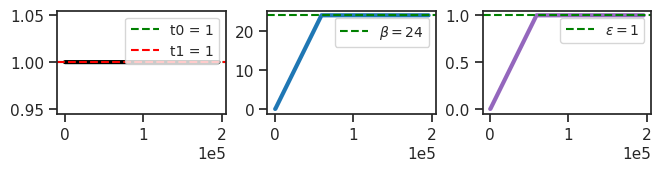

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

196000

In [6]:
print(tr.model.layer)
# print(tr.model.layer.n_exp)

GaussianSigmoidLayer(input_dim=256, latent_dim=768, temperature=1, beta_inner=1, eps=1)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>))

In [8]:
cm = f"non-whitened"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 1000, avg loss: 200.909417: 100%|█| 1000/1000 [2:37:12<00:00,  9.43s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0627], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([0.0051], device='cuda:0', grad_fn=<ExpBackward0>))

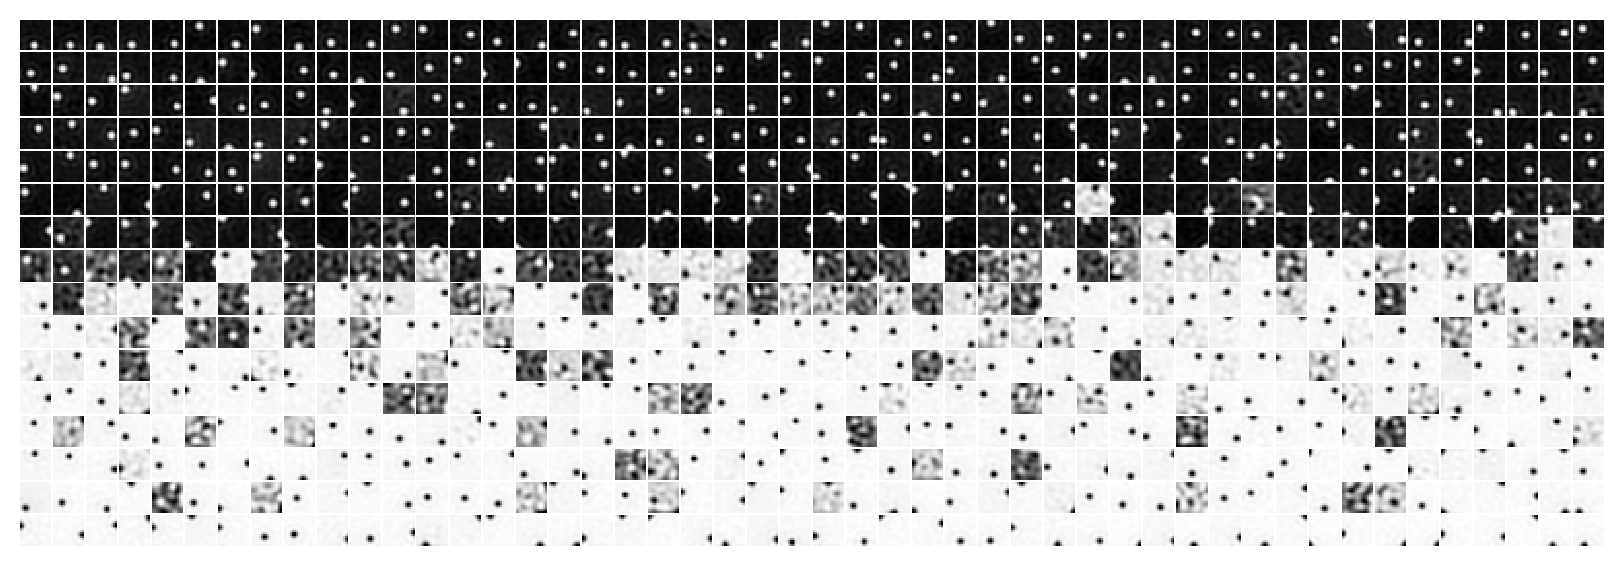

In [10]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16);

In [11]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([768, 16, 16])

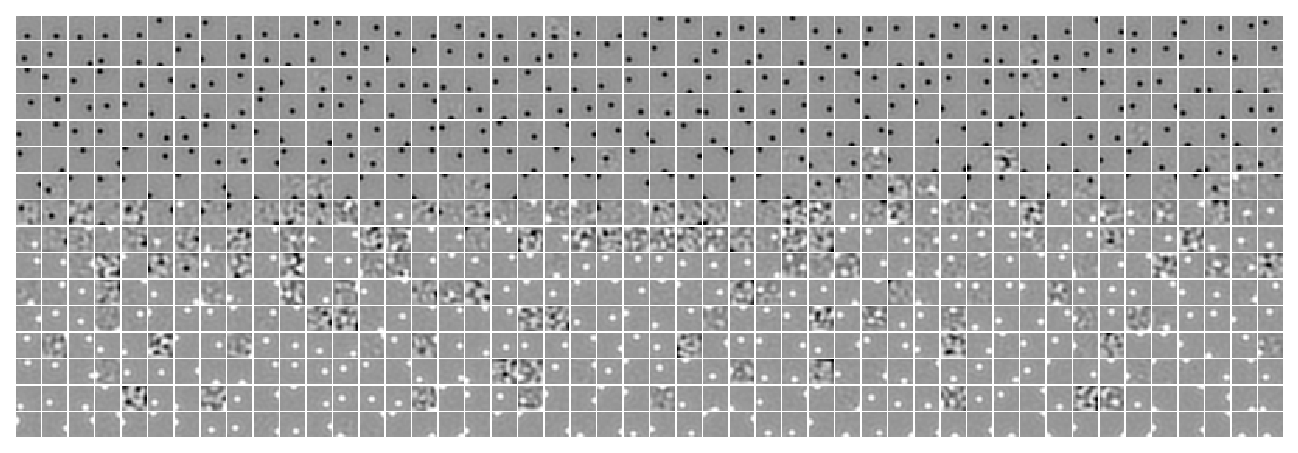

In [12]:
plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
);

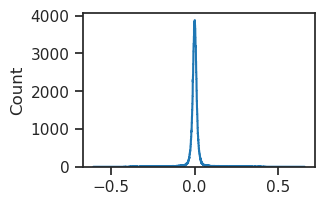

In [13]:
histplot(w.ravel())
plt.show()

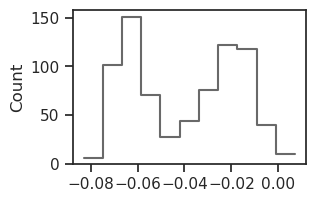

In [14]:
histplot(u0, color='dimgrey')
plt.show()

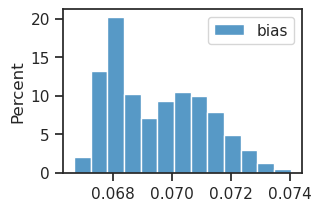

In [15]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

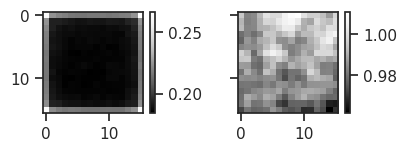

In [18]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:35<00:00, 17.97s/it]


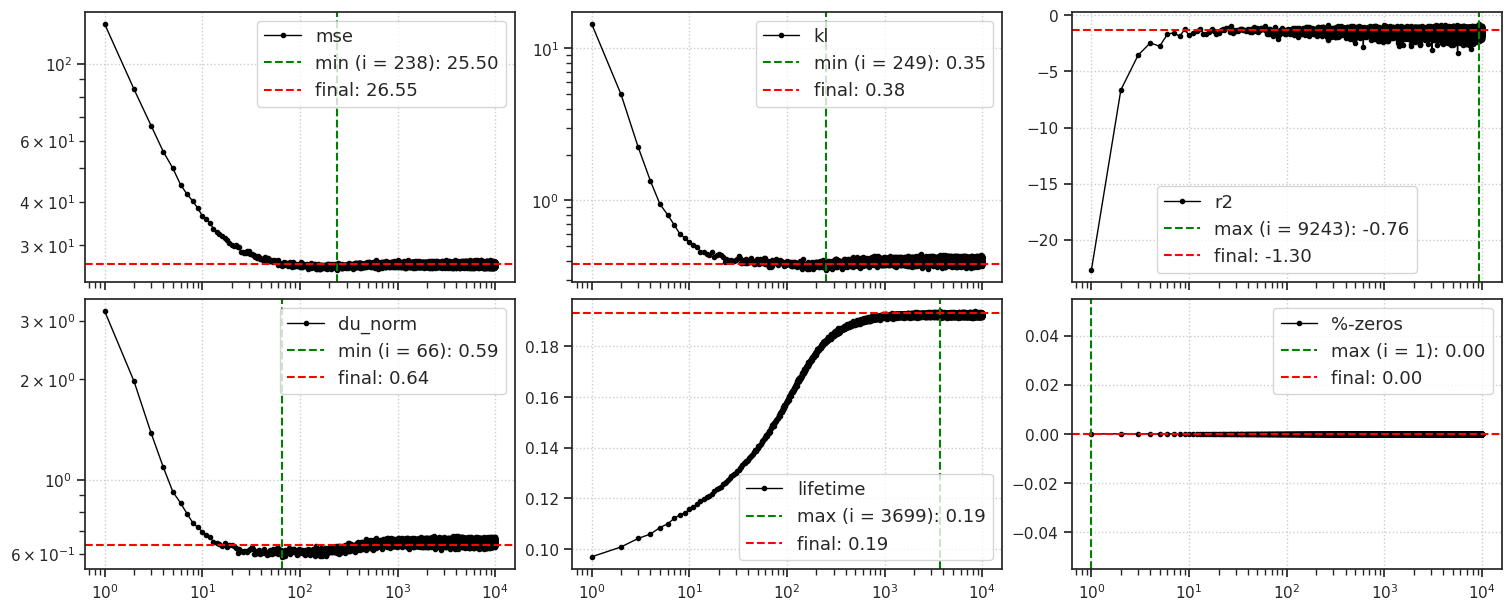

CPU times: user 46.8 s, sys: 3.54 s, total: 50.3 s
Wall time: 50.3 s


In [19]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## output

In [20]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

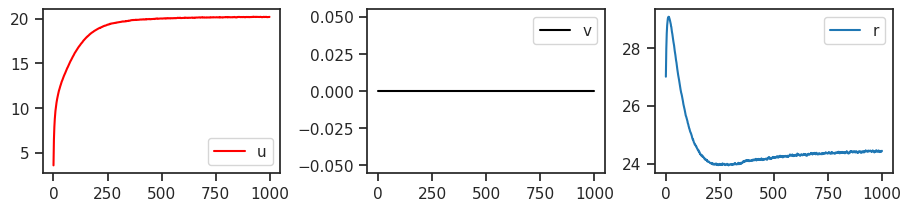

In [21]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

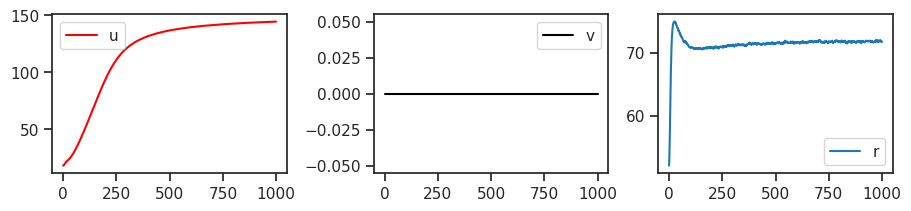

In [17]:
### Was: beta = 20.0

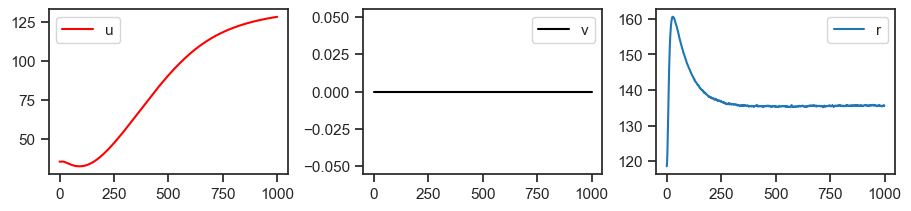

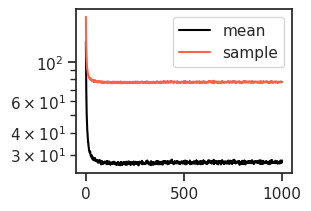

(tensor([27.3813, 27.3916, 27.0705, 27.1724, 27.8886], device='cuda:0'),
 tensor([77.5244, 77.2575, 76.9498, 76.8427, 77.4433], device='cuda:0'))

In [22]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

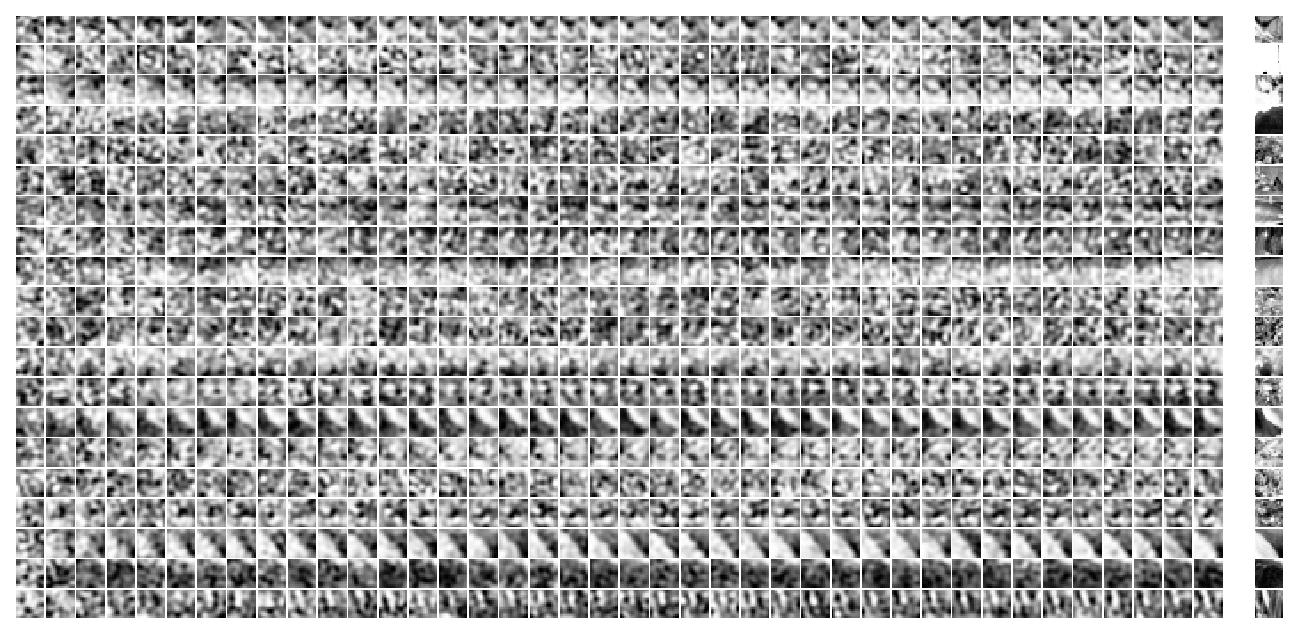

In [23]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

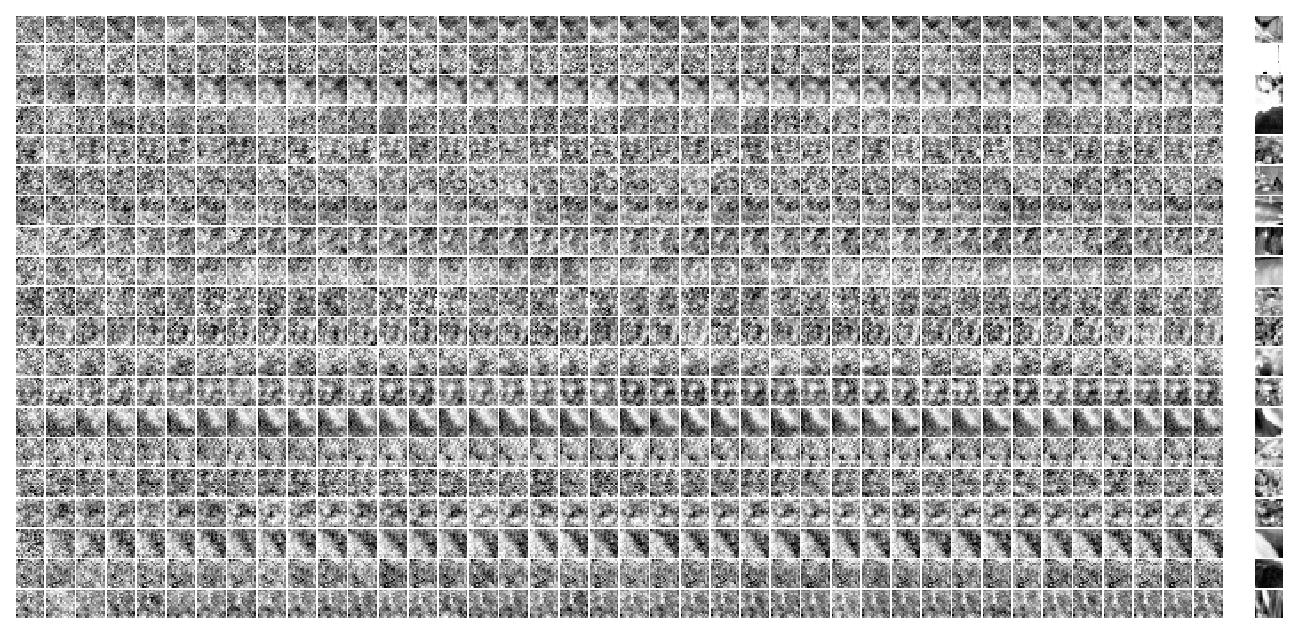

In [24]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)